# Periapical Lesion Detection — Experiment 1b
## Single-Class Model: Largest Average Bounding Box

| Experiment | Classes | Strategy |
|-----------|---------|----------|
| **exp1b** | 1 (largest box) | Single-class — easiest anchors |

All other experiments (1a, 2, 3) have been removed.  
Base architecture: **YOLOv10l**

## 1. Environment Setup

In [ ]:
!pip install ultralytics --quiet
!pip install Pillow matplotlib PyYAML --quiet

import os, shutil, random, time, math, yaml, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('=' * 55)
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('=' * 55)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.2 MB/s eta 0:00:00
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


## 2. Google Drive Mount & Path Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

WORK_DIR    = Path('/content/drive/MyDrive/Colab Notebooks/medical dataset')
DATASET_DIR = WORK_DIR / 'dataset_yolo'
yaml_path   = DATASET_DIR / 'data.yaml'
PROJECT     = str(WORK_DIR / 'runs_experiments')

CLASS_DISPLAY = ['Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
NC = len(CLASS_DISPLAY)

# Verify original dataset
checks = {
    'data.yaml'   : yaml_path,
    'train images': DATASET_DIR / 'images' / 'train',
    'valid images': DATASET_DIR / 'images' / 'valid',
    'test images' : DATASET_DIR / 'images' / 'test',
    'train labels': DATASET_DIR / 'labels' / 'train',
    'valid labels': DATASET_DIR / 'labels' / 'valid',
    'test labels' : DATASET_DIR / 'labels' / 'test',
}
print('Dataset path check:')
all_ok = True
for name, p in checks.items():
    ok = p.exists()
    all_ok = all_ok and ok
    print(f'  {"OK" if ok else "MISSING":7} {name:<15} : {p}')

assert all_ok, 'Some paths are missing. Run Notebook 1 first!'
print('\nAll paths OK.')

Mounted at /content/drive
Dataset path check:
  OK      data.yaml       : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/data.yaml
  OK      train images    : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/images/train
  OK      valid images    : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/images/valid
  OK      test images     : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/images/test
  OK      train labels    : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/labels/train
  OK      valid labels    : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/labels/valid
  OK      test labels     : /content/drive/MyDrive/Colab Notebooks/medical dataset/dataset_yolo/labels/test

All paths OK.


## 3. Label Analysis
Scan all label files (train + valid + test) to compute:
- Instance count per class
- Mean bounding-box area per class (normalised units)

The class with the **largest mean area** will be used for Experiment 1b.

Class                        Count   Mean Area (norm)  Mean Area (%)
--------------------------------------------------------------------
Periapical_Type3             11775           0.000968         0.097%
Periapical_Type4              4772           0.001959         0.196%
Periapical_Type5              1956           0.005137         0.514%

  Exp 1b — largest box class: Periapical_Type5 (idx=2, area=0.514%)


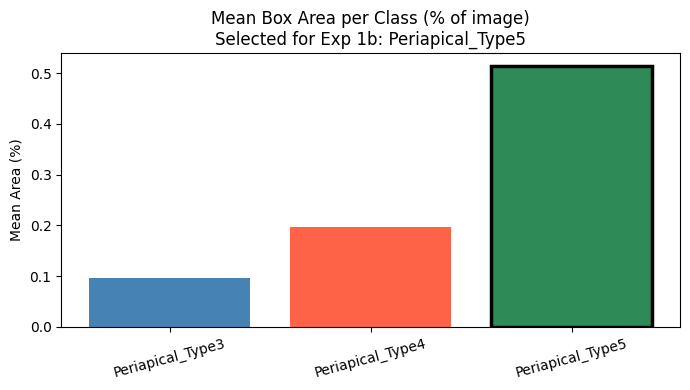

In [ ]:
def parse_labels(label_dir: Path):
    """
    Returns a dict:
      {class_idx: {'count': int, 'areas': [float, ...]}}
    Area = w * h in normalised YOLO coordinates.
    """
    stats = {i: {'count': 0, 'areas': []} for i in range(NC)}
    for txt in label_dir.glob('*.txt'):
        for line in txt.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_idx = int(parts[0])
            _, _, bw, bh = map(float, parts[1:])
            area = bw * bh
            stats[cls_idx]['count'] += 1
            stats[cls_idx]['areas'].append(area)
    return stats


# Aggregate across all splits
all_stats = {i: {'count': 0, 'areas': []} for i in range(NC)}
for split in ['train', 'valid', 'test']:
    s = parse_labels(DATASET_DIR / 'labels' / split)
    for cls_idx in range(NC):
        all_stats[cls_idx]['count'] += s[cls_idx]['count']
        all_stats[cls_idx]['areas'].extend(s[cls_idx]['areas'])

print(f'{"Class":<25} {"Count":>8} {"Mean Area (norm)":>18} {"Mean Area (%)":>14}')
print('-' * 68)
for i, name in enumerate(CLASS_DISPLAY):
    cnt   = all_stats[i]['count']
    areas = all_stats[i]['areas']
    mean_area = np.mean(areas) if areas else 0.0
    print(f'{name:<25} {cnt:>8} {mean_area:>18.6f} {mean_area*100:>13.3f}%')

# ── Identify largest-box class ─────────────────────────────────────────────
mean_areas = {
    i: (np.mean(all_stats[i]['areas']) if all_stats[i]['areas'] else 0.0)
    for i in range(NC)
}
sorted_by_area  = sorted(mean_areas, key=mean_areas.__getitem__, reverse=True)
largest_box_cls = sorted_by_area[0]

print(f'\n  Exp 1b — largest box class: {CLASS_DISPLAY[largest_box_cls]} '
      f'(idx={largest_box_cls}, area={mean_areas[largest_box_cls]*100:.3f}%)')

# Bar chart — mean area per class
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue', 'tomato', 'seagreen']
bars   = ax.bar([CLASS_DISPLAY[i] for i in range(NC)],
                [mean_areas[i] * 100 for i in range(NC)],
                color=colors)
# Highlight the selected class
bars[largest_box_cls].set_edgecolor('black')
bars[largest_box_cls].set_linewidth(2.5)
ax.set_title('Mean Box Area per Class (% of image)\n'
             f'Selected for Exp 1b: {CLASS_DISPLAY[largest_box_cls]}')
ax.set_ylabel('Mean Area (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 4. Dataset Builder Helper
Copies image/label subsets and writes a custom `data.yaml`.

In [ ]:
def build_filtered_dataset(
    dst_root      : Path,
    keep_classes  : list,
    max_per_class : int  = None,
    seed          : int  = SEED,
) -> Path:
    """
    Build a YOLO dataset that:
      - keeps only labels whose class is in keep_classes
      - re-indexes classes to 0..len(keep_classes)-1
      - optionally caps instances per class (balanced mode, train split only)
    Returns path to the new data.yaml.
    """
    rng = random.Random(seed)
    dst_root.mkdir(parents=True, exist_ok=True)

    cls_map   = {old: new for new, old in enumerate(keep_classes)}
    new_names = [CLASS_DISPLAY[c] for c in keep_classes]

    for split in ['train', 'valid', 'test']:
        img_dir = DATASET_DIR / 'images' / split
        lbl_dir = DATASET_DIR / 'labels' / split

        samples = []
        for txt in sorted(lbl_dir.glob('*.txt')):
            kept_lines = []
            for line in txt.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                old_cls = int(parts[0])
                if old_cls not in cls_map:
                    continue
                new_cls = cls_map[old_cls]
                kept_lines.append(f'{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}')
            if not kept_lines:
                continue

            img_path = None
            for ext in ['.jpg', '.jpeg', '.png']:
                p = img_dir / (txt.stem + ext)
                if p.exists():
                    img_path = p
                    break
            if img_path is None:
                continue
            samples.append((img_path, kept_lines))

        if max_per_class is not None and split == 'train':
            cls_budget = {new: max_per_class for new in range(len(keep_classes))}
            rng.shuffle(samples)
            selected = []
            for img_path, lines in samples:
                line_classes = [int(l.split()[0]) for l in lines]
                if any(cls_budget.get(c, 0) > 0 for c in line_classes):
                    for c in set(line_classes):
                        if c in cls_budget:
                            cls_budget[c] = max(0, cls_budget[c] - line_classes.count(c))
                    selected.append((img_path, lines))
            samples = selected
            print(f'  [{split}] kept {len(samples)} images after balancing (cap={max_per_class}/class)')
        else:
            print(f'  [{split}] {len(samples)} images')

        dst_img = dst_root / 'images' / split
        dst_lbl = dst_root / 'labels' / split
        dst_img.mkdir(parents=True, exist_ok=True)
        dst_lbl.mkdir(parents=True, exist_ok=True)

        for img_path, lines in samples:
            shutil.copy2(img_path, dst_img / img_path.name)
            (dst_lbl / (img_path.stem + '.txt')).write_text('\n'.join(lines))

    yaml_content = {
        'path'  : str(dst_root),
        'train' : 'images/train',
        'val'   : 'images/valid',
        'test'  : 'images/test',
        'nc'    : len(keep_classes),
        'names' : new_names,
    }
    dst_yaml = dst_root / 'data.yaml'
    with open(dst_yaml, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

    print(f'  data.yaml -> {dst_yaml}')
    print(f'  Classes   : {new_names}')
    return dst_yaml


def count_split_images(ds_root: Path) -> dict:
    totals = {}
    for split in ['train', 'valid', 'test']:
        d = ds_root / 'images' / split
        totals[split] = (
            len(list(d.glob('*.jpg'))) + len(list(d.glob('*.png')))
            if d.exists() else 0
        )
    return totals

## 5. Shared Training Helper
Single function that trains a YOLOv10l model given a `data.yaml` path.

In [ ]:
from ultralytics import YOLO

MODEL_WEIGHTS = 'yolov10l.pt'

def train_experiment(
    exp_name : str,
    data_yaml: Path,
    epochs   : int   = 70,
    imgsz    : int   = 1024,
    lr0      : float = 0.001,
) -> dict:
    """
    Train YOLOv10l and return a results summary dict.
    imgsz=640 is used to stay within T4 VRAM (15 GB).
    """
    print(f'\n{"="*60}')
    print(f'  Training: {exp_name}')
    print(f'  data    : {data_yaml}')
    print(f'{"="*60}')

    torch.cuda.empty_cache()

    model = YOLO(MODEL_WEIGHTS)
    t0 = time.time()

    results = model.train(
        data          = str(data_yaml),
        epochs        = epochs,
        imgsz         = imgsz,
        batch         = 16,
        optimizer     = 'AdamW',
        lr0           = lr0,
        lrf           = 0.01,
        cos_lr        = True,
        weight_decay  = 0.0005,
        warmup_epochs = 3,
        mosaic        = 0.5,
        fliplr        = 0.5,
        degrees       = 5,
        hsv_h         = 0.01,
        hsv_s         = 0.3,
        hsv_v         = 0.4,
        patience      = 20,
        seed          = SEED,
        exist_ok      = True,
        project       = PROJECT,
        name          = exp_name,
        plots         = True,
        cache         = False,
        workers       = 2,
        verbose       = False,
    )

    elapsed = time.time() - t0
    best_pt  = Path(PROJECT) / exp_name / 'weights' / 'best.pt'

    del model
    torch.cuda.empty_cache()

    # Evaluate on test split
    best_model = YOLO(str(best_pt))
    test_m = best_model.val(
        data     = str(data_yaml),
        split    = 'test',
        imgsz    = imgsz,
        batch    = 16,
        device   = 0,
        plots    = True,
        project  = PROJECT,
        name     = exp_name + '_test',
        exist_ok = True,
        verbose  = False,
    )

    del best_model
    torch.cuda.empty_cache()

    summary = {
        'exp_name' : exp_name,
        'best_pt'  : best_pt,
        'elapsed_h': elapsed / 3600,
        'mAP50'    : test_m.box.map50,
        'mAP50_95' : test_m.box.map,
        'precision': test_m.box.mp,
        'recall'   : test_m.box.mr,
    }

    print(f'\n  [{exp_name}] Test results:')
    print(f'    mAP50     : {summary["mAP50"]:.4f}')
    print(f'    mAP50-95  : {summary["mAP50_95"]:.4f}')
    print(f'    Precision : {summary["precision"]:.4f}')
    print(f'    Recall    : {summary["recall"]:.4f}')
    print(f'    Time      : {elapsed/3600:.2f} h')

    return summary

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 6. Experiment 1b — Single Class: Largest Average Box
Train a single-class detector on the class with the largest mean bounding box.  
This class is determined automatically from the label analysis above.

In [ ]:
EXP1B_ROOT = WORK_DIR / 'datasets' / 'exp1b_largest_box'
EXP1B_YAML = build_filtered_dataset(
    dst_root      = EXP1B_ROOT,
    keep_classes  = [largest_box_cls],
    max_per_class = None,
)
split_info = count_split_images(EXP1B_ROOT)
print(f'  Split sizes: {split_info}')

  [train] 1272 images
  [valid] 265 images
  [test] 267 images


In [ ]:
torch.cuda.empty_cache()
print("VRAM freed before exp1b")

summary_1b = train_experiment(
    exp_name  = 'exp1b_largest_box',
    data_yaml = EXP1B_YAML,
)

VRAM freed before exp1b

  Training: exp1b_largest_box
  data    : /content/drive/MyDrive/Colab Notebooks/medical dataset/datasets/exp1b_largest_box/data.yaml
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/medical dataset/datasets/exp1b_largest_box/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, ma

## 7. Results


Experiment                        mAP50   mAP50-95   Precision   Recall  Time(h)
------------------------------------------------------------------------------
exp1b_largest_box                0.8417     0.5642      0.9341   0.7729     4.27


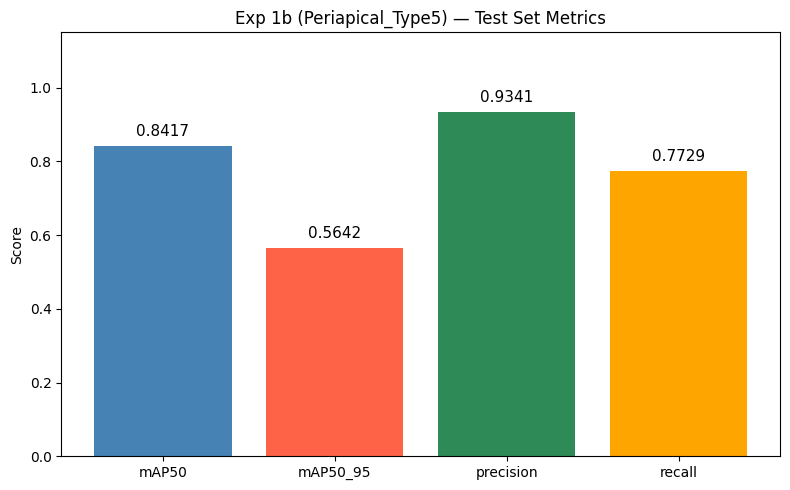

In [ ]:
print(f'\n{"Experiment":<30} {"mAP50":>8} {"mAP50-95":>10} {"Precision":>11} {"Recall":>8} {"Time(h)":>8}')
print('-' * 78)
s = summary_1b
print(f'{s["exp_name"]:<30} {s["mAP50"]:>8.4f} {s["mAP50_95"]:>10.4f} '
      f'{s["precision"]:>11.4f} {s["recall"]:>8.4f} {s["elapsed_h"]:>8.2f}')

# Bar chart
metrics = ['mAP50', 'mAP50_95', 'precision', 'recall']
vals    = [s[metric] for metric in metrics]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics, vals, color=['steelblue', 'tomato', 'seagreen', 'orange'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title(f'Exp 1b ({CLASS_DISPLAY[largest_box_cls]}) — Test Set Metrics')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Export Best Weights to Google Drive

In [ ]:
export_dir = WORK_DIR / 'exports_experiments'
export_dir.mkdir(parents=True, exist_ok=True)

pt  = summary_1b['best_pt']
dst = export_dir / 'exp1b_largest_box_best.pt'

if pt.exists():
    shutil.copy2(pt, dst)
    print(f'  Copied best.pt  ->  {dst}')
else:
    print(f'  WARNING: {pt} not found')

print('\nWeight exported to:', export_dir)

  Copied best.pt  ->  /content/drive/MyDrive/Colab Notebooks/medical dataset/exports_experiments/exp1b_largest_box_best.pt

Weight exported to: /content/drive/MyDrive/Colab Notebooks/medical dataset/exports_experiments
